In [1]:
import docling
from pathlib import Path

In [2]:
SAMPLE_DIR = Path("sample_documents")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)

print("Core imports loaded successfully!")


Core imports loaded successfully!


### 2. Basic Document Conversion
The `DocumentConverter` class is the main entry point for document conversion in Docling. It handles format detection, backend selection, and pipeline execution automatically.

Key Concepts:
- `ConversionResult`: Contains the converted document, status, and any errors
- `DoclingDocument`: The unified internal representation of any document
- `Export Formats`: Markdown, JSON, HTML, Text, DocTags

In [3]:
from docling.document_converter import DocumentConverter
from docling.datamodel.base_models import InputFormat,ConversionStatus

converter = DocumentConverter() 


pdf_url = "https://arxiv.org/pdf/2408.09869"

print(f"Converting PDF from: {pdf_url}")
print("This may take a minute for the first run as models are downloaded...")

result = converter.convert(pdf_url)
# print(result)

print(f"Conversion status: {result.status}")
print(f"Document name: {result.input.file.name}")
print(f"Number of Pages: {len(result.pages) if result.pages else 'N/A'}")


Converting PDF from: https://arxiv.org/pdf/2408.09869
This may take a minute for the first run as models are downloaded...


The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-03 22:06:07,289 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-03 22:06:07,295 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\rsurs\OneDrive\Documents\Root\rag-course\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-03 22:06:07,296 [RapidOCR] main.py:57: Using C:\Users\rsurs\OneDrive\Documents\Root\rag-course\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-03 22:06:07,387 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-03 22:06:07,392 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\rsurs\OneDrive\Documents\Root\rag-course\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.


Conversion status: ConversionStatus.SUCCESS
Document name: 2408.09869
Number of Pages: 9


### with the output of `DocumentConverter` we can:

- get status `result.status`

- get document `result.document`

- export to doc markdown,json 

`md = doc.export_to_markdown()`

`json_data = doc.export_to_dict()`

- inspect tables and text in doc 
```
for table in doc.tables:
    print(table)
```


In [4]:
doc = result.document
doc

DoclingDocument(schema_name='DoclingDocument', version='1.10.0', name='2408', origin=DocumentOrigin(mimetype='application/pdf', binary_hash=11465328351749295394, filename='2408.09869', uri=None), furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>), body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0'), RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/texts/3'), RefItem(cref='#/texts/4'), RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/groups/0'), RefItem(cref='#/texts/20'), RefItem(cref='#/texts/21'), RefItem(cref='#/texts/22'), RefItem(cref='#/texts/23'), RefItem(cref='#/texts/24')

In [5]:
print(f"document type: {type(doc)}")
print(f"Number of tables: {len(doc.tables) if hasattr(doc,'tables') else 0}")
print(f"Number of pictures: {len(doc.pictures) if hasattr(doc,"pictures") else 0}")

document type: <class 'docling_core.types.doc.document.DoclingDocument'>
Number of tables: 3
Number of pictures: 5


In [6]:
if hasattr(doc,'tables') and doc.tables:
    for i,table in enumerate(doc.tables):
        print(f"\n--- Table {i+1} ---")
        # Export table to markdown format
        print(table.export_to_markdown(doc))

else:
    print("No table found")

print("\n" + "=" * 50)
print("PICTURES")
print("=" * 50)

if hasattr(doc,'pictures') and doc.pictures:
    for i,picture in enumerate(doc.pictures):
        print(f"\n--- Picture {i+1} ---")
        
        # get the caption or text associated with pic 
        if hasattr(picture,"captions") and picture.captions:
            print(f"caption: {picture.captions}")
        
        if hasattr(picture,'caption_text') and picture.caption_text:
            print(f"text: {picture.caption_text}")
        
        if hasattr(picture,'prov') and picture.prov:
            print(f"Provenance: {picture.prov}")

else:
    print(f"No picture found")



--- Table 1 ---
Table 1: Runtime characteristics of Docling with the standard model pipeline and settings, on our test dataset of 225 pages, on two different systems. OCR is disabled. We show the time-to-solution (TTS), computed throughput in pages per second, and the peak memory used (resident set size) for both the Docling-native PDF backend and for the pypdfium backend, using 4 and 16 threads.

| CPU                     | Thread budget   | native backend   | native backend   | native backend   | pypdfium backend   | pypdfium backend   | pypdfium backend   |
|-------------------------|-----------------|------------------|------------------|------------------|--------------------|--------------------|--------------------|
|                         |                 | TTS              | Pages/s          | Mem              | TTS                | Pages/s            | Mem                |
| Apple M3 Max (16 cores) | 4 16            | 177 s 167 s      | 1.27 1.34        | 6.20 GB         

### Export formats

Docling supports multiple export formats:
- markdown  (LLM input,readable output)
- json (Programmatic access)
- html (Web display)
- text (Simple text extractions)

In [7]:
md_content = doc.export_to_markdown()
print("=" * 80)
print("MARKDOWN OUTPUT (first 2000 chars)")
print("=" * 80)
print(md_content[:2000])
print("\n... [truncated] ...")


MARKDOWN OUTPUT (first 2000 chars)
<!-- image -->

## Docling Technical Report

## Version 1.0

Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber Lucas Morin Ingmar Meijer Viktor Kuropiatnyk Peter W. J. Staar

AI4K Group, IBM Research R¨ uschlikon, Switzerland

## Abstract

This technical report introduces Docling , an easy to use, self-contained, MITlicensed open-source package for PDF document conversion. It is powered by state-of-the-art specialized AI models for layout analysis (DocLayNet) and table structure recognition (TableFormer), and runs efficiently on commodity hardware in a small resource budget. The code interface allows for easy extensibility and addition of new features and models.

## 1 Introduction

Converting PDF documents back into a machine-processable format has been a major challenge

In [8]:
# export to json 
json_output_path = OUTPUT_DIR / "docling_parser.json"
doc.save_as_json(json_output_path)
print(f"JSON saved to: {json_output_path}")

html_output_path = OUTPUT_DIR / "docling_paper.html"
doc.save_as_html(html_output_path)
print(f"HTML saved to: {html_output_path}")

# Export to Markdown file
md_output_path = OUTPUT_DIR / "docling_paper.md"
with open(md_output_path, "w",encoding="utf-8") as f:
    f.write(md_content)
print(f"Markdown saved to: {md_output_path}")


JSON saved to: output\docling_parser.json
HTML saved to: output\docling_paper.html
Markdown saved to: output\docling_paper.md


In [9]:
# export doc to dict 
doc_dict = doc.export_to_dict()
print("Document dictionary keys:")
for key in doc_dict.keys():
    print(f" - {key}")

Document dictionary keys:
 - schema_name
 - version
 - name
 - origin
 - furniture
 - body
 - groups
 - texts
 - pictures
 - tables
 - key_value_items
 - form_items
 - pages


In [10]:
print("ConversionResult Attributes:")
print(f" status: {result.status}")
print(f" input.file: {result.input.file}")
print(f"  input.format: {result.input.format}")
print(f"  input.document_hash: {result.input.document_hash[:16]}...")

# Check for errors
if result.errors:
    print(f"\nErrors ({len(result.errors)}):")
    for error in result.errors:
        print(f"  - {error.component_type}: {error.error_message}")
else:
    print("\nNo errors during conversion!")


ConversionResult Attributes:
 status: ConversionStatus.SUCCESS
 input.file: 2408.09869
  input.format: InputFormat.PDF
  input.document_hash: 82dd470712ce8389...

No errors during conversion!


### PDF Docs

PDF is the most feature-rich format with support for:

- Layout analysis (headers, paragraphs, lists)
- Table structure extraction
- OCR for scanned pages
- Image/figure extraction
- Reading order determination

In [11]:
from docling.document_converter import DocumentConverter,PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

# PdfPipelineOptions contains configuration settings for pdf processing

pdf_options = PdfPipelineOptions(do_ocr=False, # ocr converts images into text, disable for native pdf
                                 do_table_structure=True, # extracts tables in rows and cols
                                 generate_page_images=True) # create an image for every pdf page

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_options)
    }
)

# Convert the PDF
result = converter.convert(pdf_url)
print(f"Conversion status: {result.status}")


Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

Conversion status: ConversionStatus.SUCCESS


DoclingDocument(schema_name='DoclingDocument', version='1.10.0', name='2408', origin=DocumentOrigin(mimetype='application/pdf', binary_hash=11465328351749295394, filename='2408.09869', uri=None), furniture=GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>), body=GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0'), RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/1'), RefItem(cref='#/texts/2'), RefItem(cref='#/texts/3'), RefItem(cref='#/texts/4'), RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/groups/0'), RefItem(cref='#/texts/20'), RefItem(cref='#/texts/21'), RefItem(cref='#/texts/22'), RefItem(cref='#/texts/23'), RefItem(cref='#/texts/24')
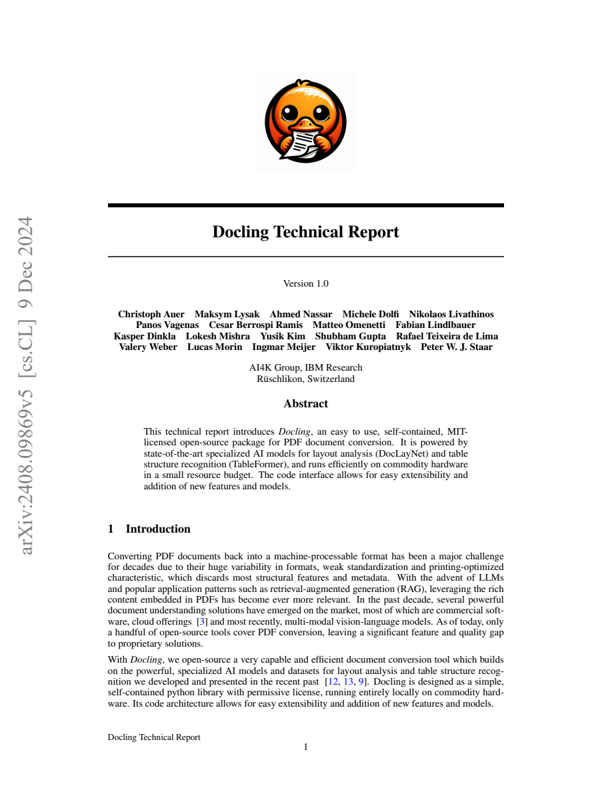
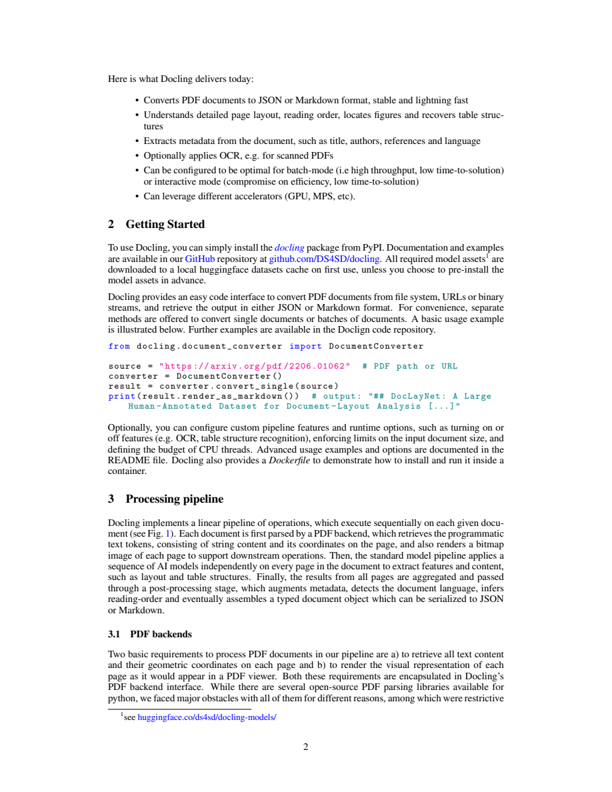
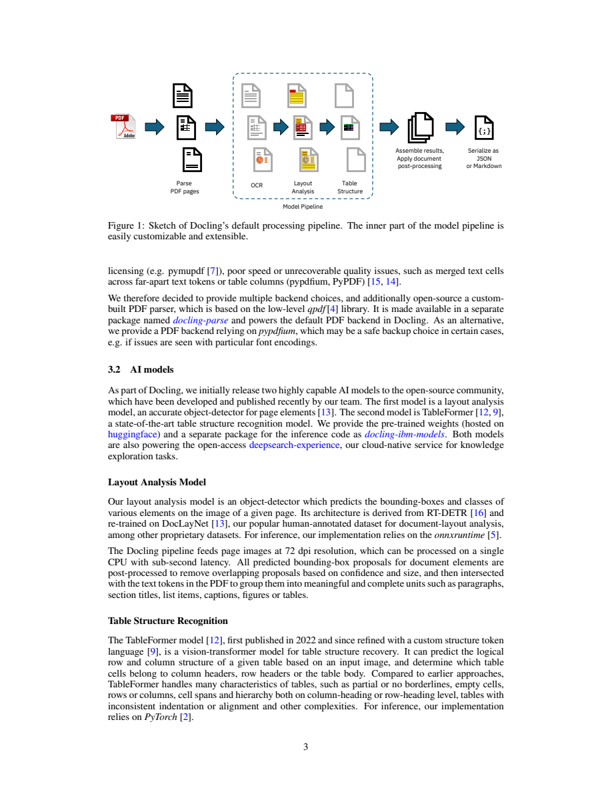
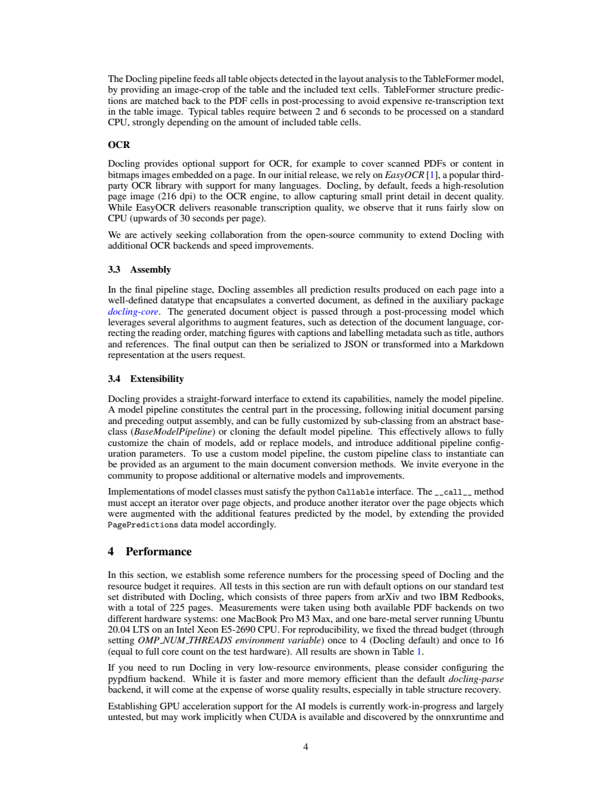
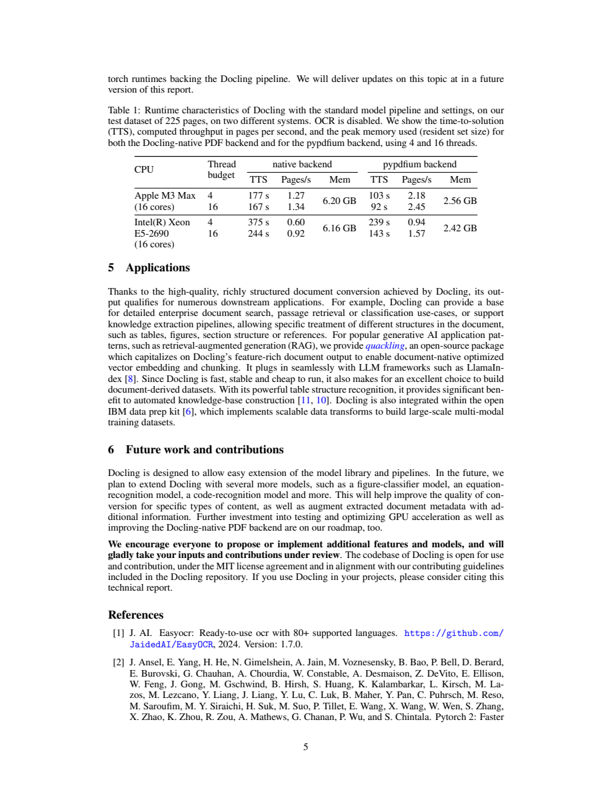
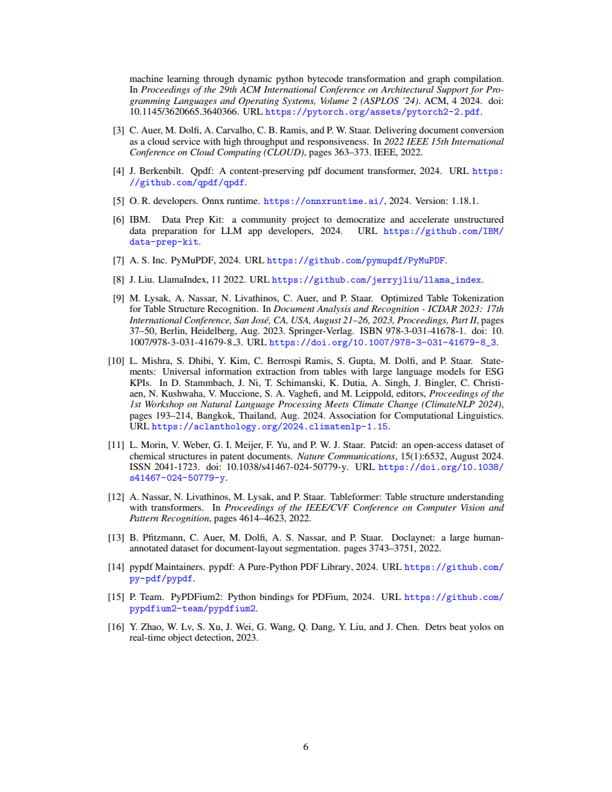
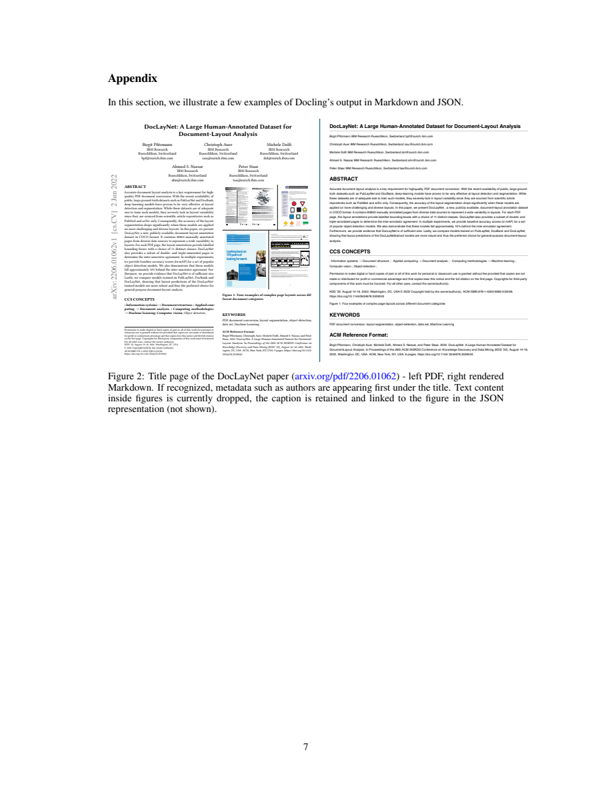
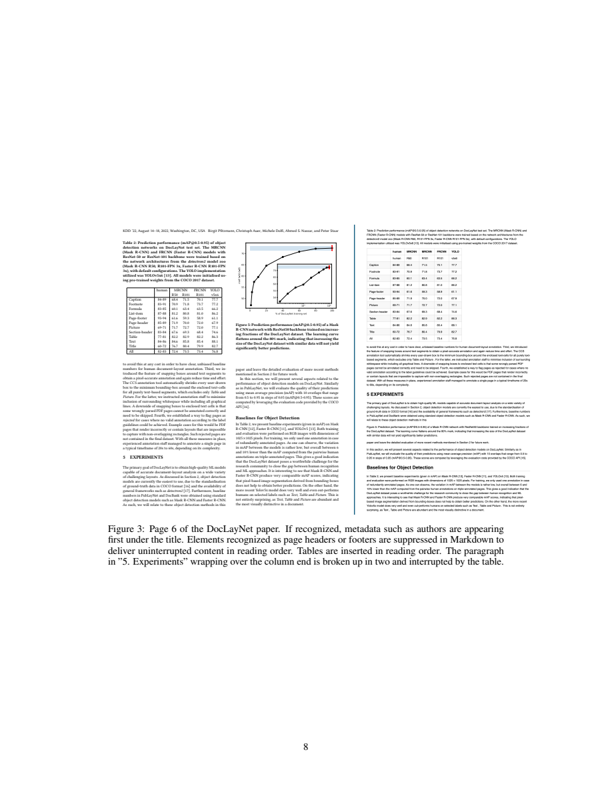
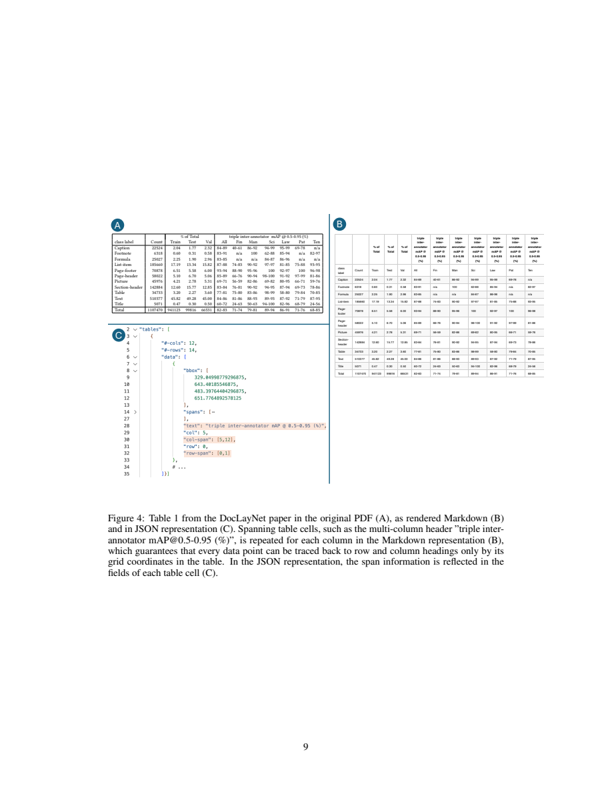

In [12]:
doc = result.document
doc

In [13]:
if hasattr(doc,'tables') and doc.tables:
    print(f"Found {len(doc.tables)} tables in the document")

    for i,table in enumerate(doc.tables[:2]):
        print(f"Table {i+1}:")
        print("-" * 40)
        
        # Try to export to DataFrame if pandas is available
        try:
            df = table.export_to_dataframe(doc)
            print(df.head())
        except Exception as e:
            print(f"Table markdown: {table.export_to_markdown()[:500]}")
        print()
else:
    print("No tables found in the document")

Found 3 tables in the document
Table 1:
----------------------------------------
                      CPU. Thread budget. native backend.TTS  \
0  Apple M3 Max (16 cores)           4 16        177 s 167 s   
1    Intel(R) Xeon E5-2690           4 16        375 s 244 s   

  native backend.Pages/s native backend.Mem pypdfium backend.TTS  \
0              1.27 1.34            6.20 GB           103 s 92 s   
1              0.60 0.92            6.16 GB          239 s 143 s   

  pypdfium backend.Pages/s pypdfium backend.Mem  
0                2.18 2.45              2.56 GB  
1                0.94 1.57              2.42 GB  

Table 2:
----------------------------------------
                                                      \
0  Caption Footnote Formula List-item Page-footer...   

                                               human  \
0  84-89 83-91 83-85 87-88 93-94 85-89 69-71 83-8...   

                                      MRCNN R50 R101  \
0  68.4 71.5 70.9 71.8 60.1 63.4 81.2 

### Microsoft Office documents 
Docling supports (docx,pptx,xlsx) with rich formatting preservation

In [14]:
from docling.document_converter import DocumentConverter

converter = DocumentConverter()

html_path =  SAMPLE_DIR / "sample.html"

if html_path.exists():
    result = converter.convert(html_path)
    print(f"Conversion status: {result.status}")

    html_markdown = result.document.export_to_markdown()
    print(f"\nConverted HTML to markdown:")
    print("=" * 60)
    print(html_markdown[:1500])
else:
    print(f"Sample HTML file not found at {html_path}")


Conversion status: ConversionStatus.SUCCESS

Converted HTML to markdown:
# Introduction to Document Parsing

A comprehensive guide to understanding document parsing techniques

## 1. Overview

Document parsing is the process of analyzing and extracting structured information from various document formats. This includes PDFs, Word documents, HTML pages, and more.

### 1.1 Key Benefits

- Automated data extraction
- Structured content analysis
- Integration with AI/ML pipelines
- Support for multiple formats

## 2. Core Features

Modern document parsers offer a variety of features:

| Feature          | Description                                         | Use Case                         |
|------------------|-----------------------------------------------------|----------------------------------|
| OCR Support      | Optical Character Recognition for scanned documents | Scanned PDFs, Images             |
| Table Extraction | Structured table data extraction                    | Financi

In [15]:
# Convert Markdown document
md_path = SAMPLE_DIR / "sample.md"

if md_path.exists():
    result = converter.convert(str(md_path))
    print(f"Markdown Conversion Status: {result.status}")
    
    # Markdown to Markdown (demonstrates parsing and re-export)
    output_md = result.document.export_to_markdown()
    print("\nParsed and re-exported Markdown:")
    print("=" * 60)
    print(output_md[:1500])
else:
    print(f"Sample Markdown file not found at {md_path}")


Markdown Conversion Status: ConversionStatus.SUCCESS

Parsed and re-exported Markdown:
# Document Parsing Best Practices

A comprehensive guide to document parsing for RAG systems.

## Table of Contents

1. [Introduction](#introduction)
2. [Supported Formats](#supported-formats)
3. [Parsing Strategies](#parsing-strategies)
4. [Integration Guide](#integration-guide)

## Introduction

Document parsing is a critical component in modern AI applications. It enables the extraction of structured information from unstructured documents, making it possible to:

- Build searchable knowledge bases
- Create training datasets for machine learning
- Enable semantic search and retrieval
- Power question-answering systems

**Note:** The quality of document parsing directly impacts the performance of downstream AI applications.

## Supported Formats

### Primary Formats

`.pdf` `.docx` `.xlsx` `.pptx` `.html` `.md`

| Format   | Extension   | Description   |
|----------|-------------|---------------|
|

In [16]:
# converting docx file 
from docling.datamodel.base_models import InputFormat
from docling.document_converter import DocumentConverter,WordFormatOption

converter = DocumentConverter(allowed_formats=[InputFormat.PPTX,
                                               InputFormat.DOCX,
                                               InputFormat.XLSX])

print("Excel (DOCX) Conversion:")
print("-" * 40)
result = converter.convert("sample_documents/sample.docx")
docx = result.document
docx_markdown = docx.export_to_markdown()

print("Word document conversion pattern demonstrated.")
print("To convert a Word document, use: converter.convert('your_document.docx')")
print(docx_markdown)


Excel (DOCX) Conversion:
----------------------------------------
Word document conversion pattern demonstrated.
To convert a Word document, use: converter.convert('your_document.docx')
# Deepfake Technology: A Technical Analysis of GAN-Based Synthetic Media

Technical Report

## Introduction

Deepfake technology represents one of the most significant applications of artificial intelligence. The term "deepfake" combines "deep learning" and "fake," referring to synthetic media where a person's face, body, or voice is digitally altered (Sharma &amp; Kaur, 2022).

**Key Statistics:**

- Projected 8 million deepfakes will be shared in 2025
- Significant increase from 500,000 in 2023 (European Parliament, 2025)
- 49% of companies experienced audio/video deepfakes in 2024

## Technical Foundation: Generative Adversarial Networks

The core technology behind deepfakes is Generative Adversarial Networks (GANs), introduced by Goodfellow et al. in 2014. GANs use two competing neural networks:

- 

### Image files with OCR

Images are processed through the same pipeline as pdf, with OCR enabled to extract text.

In [ ]:
from docling.document_converter import DocumentConverter,ImageFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

image_pipeline_options = PdfPipelineOptions(do_ocr=True)

converter = DocumentConverter(format_options={
    InputFormat.IMAGE:ImageFormatOption(
        pipeline_options=image_pipeline_options
    )
})

result = converter.convert(r"sample_documents/scan.pdf")
text = result.document.export_to_markdown()

print("Image OCR conversion pattern:")
print("-" * 40)
print(text)
print("Supported formats: PNG, JPEG, TIFF, BMP, WEBP")
print("Multi-page TIFF files are automatically handled.")
